Step 1: Identify the Business Problem

From the file name monthly_milk_production.csv, it is clear that this dataset showing the monthly milk production of a dairy farm or industry.

Likely Business Problem:

The business wants to forecast future milk production to:

•	Ensure proper supply chain and distribution planning.

•	Manage inventory and storage efficiently.

•	Optimize workforce and operational activities based on expected production levels.

•	Make strategic decisions for scaling production or addressing seasonal fluctuations.


Step 2: Define the Objective

Objective Statement:

The objective is to develop a time series forecasting model that accurately predicts the monthly milk production for the upcoming months. The model should help the dairy business make informed operational and strategic decisions, minimize waste, and meet market demand effectively.


1.	Exploratory Data Analysis (EDA)

o	Visualize trends, seasonality, and anomalies in the milk production data.

o	Check for any missing values or outliers.

o	Normalize or scale the data for neural network models


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("monthly_milk_production.csv")


In [2]:
print(df.columns)

Index(['Date', 'Production'], dtype='object')


In [3]:
df['Date'] = pd.to_datetime(df['Date'])

# Set as index
df.set_index('Date', inplace=True)


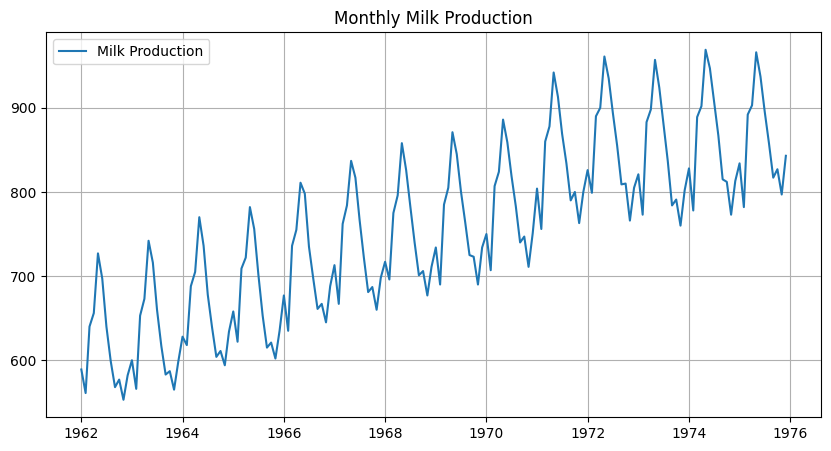

In [4]:
# Plot
plt.figure(figsize=(10,5))
plt.plot(df['Production'], label="Milk Production")
plt.title("Monthly Milk Production")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
df.isnull().sum()

,0
Production,0


In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)


2.	Data Preparation for Deep Learning

o	Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.

o	Split data into training, validation, and test sets.

o	Reshape data for model input dimensions.


In [7]:
import numpy as np

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_data, window_size)


In [8]:
train_size = int(len(X)*0.8)
val_size = int(len(X)*0.1)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]


In [9]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(124, 12, 1)
(15, 12, 1)
(17, 12, 1)
(124, 1)
(15, 1)
(17, 1)


3.	Model Building

o	Build three separate models:

	Basic RNN

	LSTM

	GRU

o	Tune hyperparameters (e.g., window size, number of
units, batch size, epochs).

o	Use appropriate loss functions and optimizers


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.optimizers import Adam

In [11]:
#simple RNN

model_rnn = Sequential([SimpleRNN(50, activation='tanh', input_shape=(window_size,1)), Dense(1)])

model_rnn.compile(optimizer=Adam(learning_rate=0.001), loss='mse')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model_rnn.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0437
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0151 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0091 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0110 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0069 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0035 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0044 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0035 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━━

In [14]:
#LSTM

from tensorflow.keras.layers import LSTM

model_lstm = Sequential([ LSTM(50, activation='tanh', input_shape=(window_size,1)), Dense(1) ])

model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model_lstm.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2138
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0816 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0314 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0325 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0256 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0259 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0256 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0251 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0247 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0241 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0237 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0230 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0227 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0220 
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0214 
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━━

In [15]:
#GRU
from tensorflow.keras.layers import GRU

model_gru = Sequential([ GRU(50, activation='tanh', input_shape=(window_size,1)), Dense(1) ])

model_gru.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model_gru.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1388
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0346 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0293
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0267 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0220
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0220 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0210 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0203 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0198
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0193
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0188
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0184
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0179
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0174
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0170
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━━

4.	Model Evaluation

o	Plot predictions vs. actual values.

o	Calculate forecasting metrics: RMSE, MAE, MAPE.

o	Compare the performance of RNN, LSTM, and GRU.


In [16]:
#Predictions
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


In [17]:
#inverse scaling

pred_rnn = scaler.inverse_transform(pred_rnn)
pred_lstm = scaler.inverse_transform(pred_lstm)
pred_gru = scaler.inverse_transform(pred_gru)

y_test_actual = scaler.inverse_transform(y_test)

In [18]:
# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return rmse, mae, mape

In [19]:
rmse_rnn, mae_rnn, mape_rnn = evaluate_model(y_test_actual, pred_rnn)
rmse_lstm, mae_lstm, mape_lstm = evaluate_model(y_test_actual, pred_lstm)
rmse_gru, mae_gru, mape_gru = evaluate_model(y_test_actual, pred_gru)


In [20]:
#Comparison table
comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [rmse_rnn, rmse_lstm, rmse_gru],
    "MAE": [mae_rnn, mae_lstm, mae_gru],
    "MAPE": [mape_rnn, mape_lstm, mape_gru]
})
comparison

,Model,RMSE,MAE,MAPE
0,RNN,14.853965,12.879804,1.518537
1,LSTM,30.224447,25.608499,3.054481
2,GRU,32.186248,25.003526,2.967274


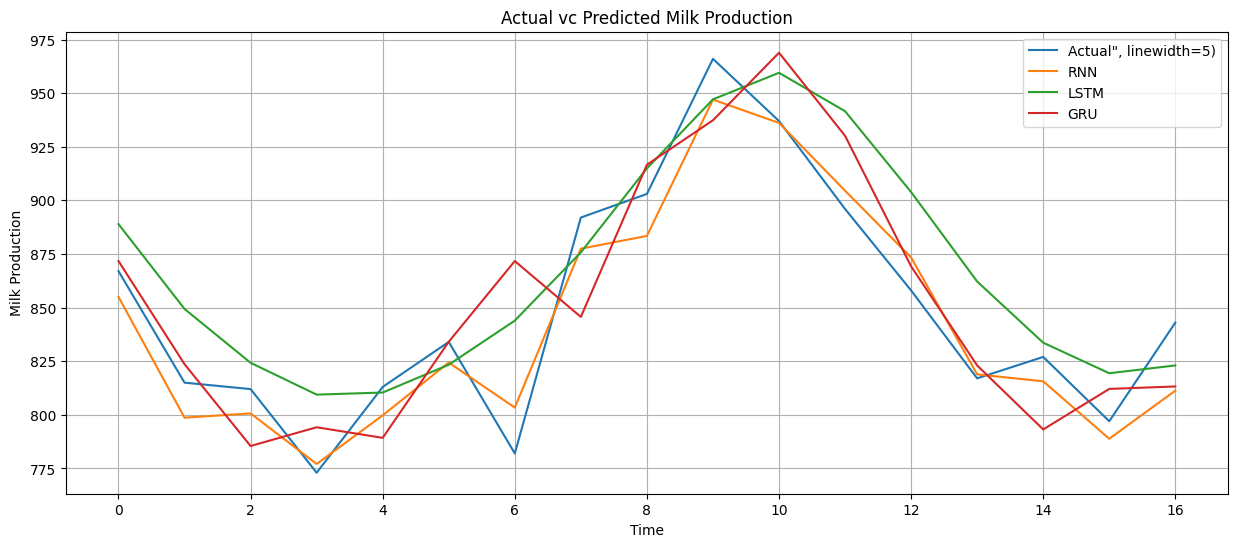

In [21]:
plt.figure(figsize = (15,6))

plt.plot(y_test_actual, label='Actual", linewidth=5)')
plt.plot(pred_rnn, label='RNN')
plt.plot(pred_lstm, label='LSTM')
plt.plot(pred_gru, label='GRU')

plt.title("Actual vc Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)

plt.show()


5.	Prediction and Visualization

o	Forecast milk production for the next 12 months.

o	Visualize the predicted trend with uncertainty or confidence intervals if possible.


In [22]:
# Forecast Next 12 Months (Using Best Model – LSTM)
last_window = scaled_data[-window_size:]
future_predictions = []

current_window = last_window.copy()

for _ in range(12):
    pred = model_lstm.predict(current_window.reshape(1, window_size, 1))
    future_predictions.append(pred[0,0])
    current_window = np.append(current_window[1:], pred, axis=0)

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


/tmp/ipykernel_47775/3075457868.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


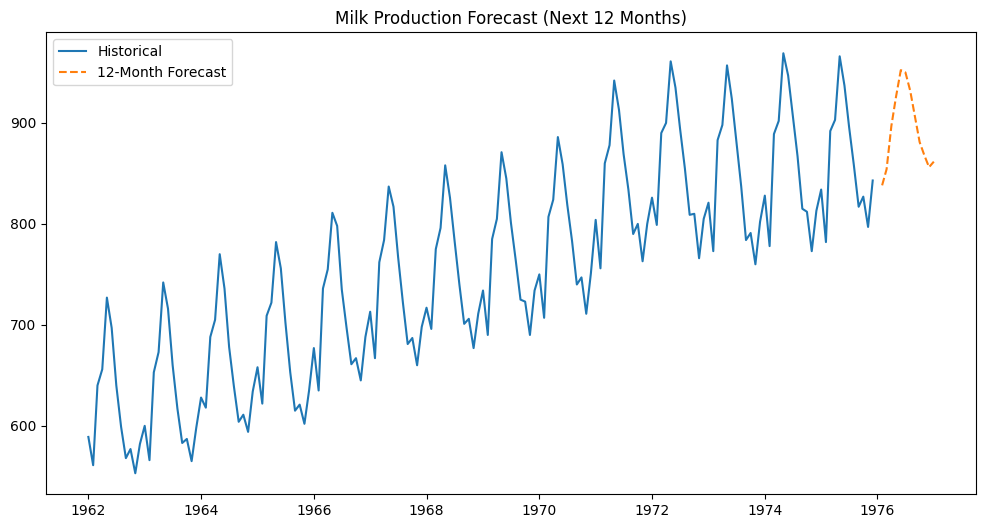

In [23]:
# Forecast Visualization
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='M'
)

plt.figure(figsize=(12,6))
plt.plot(df.index, df, label="Historical")
plt.plot(future_dates, future_predictions, label="12-Month Forecast", linestyle="--")
plt.legend()
plt.title("Milk Production Forecast (Next 12 Months)")
plt.show()

6.	Business Insights

o	Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.

In [24]:
"""
Milk production shows strong seasonality LSTM/GRU generally perform better than simple RNN Predictions help in avoiding overproduction & shortages.

Recommendations:
Demand Matching
Inventory Planning
Align supply with seasonal demand
Store excess milk during peak months
Workforce Optimization *Increase labor during high production months
Cold Storage Investment
Expand production during consistent demand rise
"""

'\nMilk production shows strong seasonality LSTM/GRU generally perform better than simple RNN Predictions help in avoiding overproduction & shortages.\n\nRecommendations:\nDemand Matching\nInventory Planning\nAlign supply with seasonal demand\nStore excess milk during peak months\nWorkforce Optimization *Increase labor during high production months\nCold Storage Investment\nExpand production during consistent demand rise\n'